# About This Notebook

Rice production-side efficiency analysis for Rice Supply Chain DMUs (Decision Making Units) in West Java Province, Indonesia.

The pipeline focused on: How efficiently each DMU converts land and production input costs into rice production value.


# Main Objective

Evaluate the production-side efficiency of rice supply chain DMUs in West Java Province by comparing land area and input costs against production value.


# Business Question

How can we increase farmers’ economic efficiency: achieving higher production value and net return while keeping input costs lower or better controlled?

## Supporting Questions

1. Which DMU are performing the best, and why? this is not just a highest production value, but efficiency based on input cost and land area.

2. Which input cost categories contribute the most to total production cost and hurting profability the most? if we reduce the cost category, does it improve DMU profitability?

3. Which input costs appear to have the strongest relationship with production value and net return?

4. Are larger DMU more efficient? or do they only generate higher production value because they use more land?

5. Which farmers have high input costs but relatively low production value or net return? (and why?)

6. How does economic performance differ across regencies where regional information is available?

Although the dataset is related to the rice supply chain, the available variables mainly represent production-side input costs and output value. Therefore, this analysis focuses on rice production efficiency, not full supply chain logistics or market distribution.


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter, PercentFormatter, MaxNLocator

sns.set_theme(style="whitegrid", palette="deep")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

## Load the Data


In [61]:
df = pd.read_excel(
    "Rice Supply Chain in West Java Province, Indonesia.xlsx",
    skiprows=1,    
)

df.head()

,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR),Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,1,2800,4900000,1400000,644000,3640000,364000,470000,16200000,NaN,NaN,NaN,NaN
1,2,1400,4900000,500000,322000,1820000,182000,540000,8100000,NaN,NaN,NaN,NaN
2,3,2000,2000000,700000,200000,2600000,260000,690000,14850000,NaN,NaN,NaN,NaN
3,4,1000,1800000,800000,230000,1300000,100000,340000,13050000,NaN,NaN,NaN,NaN
4,5,800,1520000,580000,184000,1040000,104000,350000,10200000,NaN,NaN,NaN,NaN


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   dmu                              408 non-null    object 
 1   Land area (m2)                   404 non-null    object 
 2   Land lease value (IDR)           404 non-null    object 
 3   Labor cost (IDR)                 404 non-null    object 
 4   Seed purchase value (IDR)        404 non-null    object 
 5   Fertilizer purchase value (IDR)  404 non-null    object 
 6   Pesticide purchase value (IDR)   404 non-null    object 
 7   Equipment rent value (IDR)       404 non-null    object 
 8   Production value (IDR)           404 non-null    object 
 9   Unnamed: 9                       0 non-null      float64
 10  Unnamed: 10                      0 non-null      float64
 11  Unnamed: 11                      0 non-null      float64
 12  Unnamed: 12           

In [63]:
df[df["Unnamed: 12"].notna()]

,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR),Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Count Beli


## Raw Data Cleaning


In [64]:
clean_df = df.copy()

In [65]:
# data contains alot of missing value, lets make the summary

missing_summary = pd.DataFrame({
    "missing_count": clean_df.isna().sum(),
    "missing_percentage": round(clean_df.isna().mean() * 100, 2),
    "dtype": clean_df.dtypes
})

missing_summary

,missing_count,missing_percentage,dtype
dmu,167,29.04,object
Land area (m2),171,29.74,object
Land lease value (IDR),171,29.74,object
Labor cost (IDR),171,29.74,object
Seed purchase value (IDR),171,29.74,object
Fertilizer purchase value (IDR),171,29.74,object
Pesticide purchase value (IDR),171,29.74,object
Equipment rent value (IDR),171,29.74,object
Production value (IDR),171,29.74,object
Unnamed: 9,575,100.00,float64


In [66]:
# unnamed column should be all empty, we can safely drop them

unnamed_cols = [col for col in clean_df.columns if str(col).startswith("Unnamed")]

for col in unnamed_cols:
    non_empty = clean_df[clean_df[col].notna()][col]
    print(f"\nColumn: {col}")
    print(non_empty)


Column: Unnamed: 9
Series([], Name: Unnamed: 9, dtype: float64)

Column: Unnamed: 10
Series([], Name: Unnamed: 10, dtype: float64)

Column: Unnamed: 11
Series([], Name: Unnamed: 11, dtype: float64)

Column: Unnamed: 12
574    Count Beli
Name: Unnamed: 12, dtype: object


In [67]:
# drop empty columns

clean_df = clean_df.drop(columns=["Unnamed: 9", "Unnamed: 10", "Unnamed: 11", "Unnamed: 12"])

In [68]:
# rename to better columns name

clean_df = clean_df.rename(columns={
    "dmu": "dmu",
    "Land area (m2)": "land_area_m2",
    "Land lease value (IDR)": "land_lease_value_idr",
    "Labor cost (IDR)": "labor_cost_idr",
    "Seed purchase value (IDR)": "seed_purchase_value_idr",
    "Fertilizer purchase value (IDR)": "fertilizer_purchase_value_idr",
    "Pesticide purchase value (IDR)": "pesticide_purchase_value_idr",
    "Equipment rent value (IDR)": "equipment_rent_value_idr",
    "Production value (IDR)": "production_value_idr"
})

In [69]:
# dmu act as a data identifier, so its not a part of the numerical features

raw_cols = clean_df.columns
print(raw_cols)

numeric_cols = [col for col in raw_cols if col != 'dmu']
numeric_cols

Index(['dmu', 'land_area_m2', 'land_lease_value_idr', 'labor_cost_idr',
       'seed_purchase_value_idr', 'fertilizer_purchase_value_idr',
       'pesticide_purchase_value_idr', 'equipment_rent_value_idr',
       'production_value_idr'],
      dtype='object')


['land_area_m2',
 'land_lease_value_idr',
 'labor_cost_idr',
 'seed_purchase_value_idr',
 'fertilizer_purchase_value_idr',
 'pesticide_purchase_value_idr',
 'equipment_rent_value_idr',
 'production_value_idr']

In [70]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   dmu                            408 non-null    object
 1   land_area_m2                   404 non-null    object
 2   land_lease_value_idr           404 non-null    object
 3   labor_cost_idr                 404 non-null    object
 4   seed_purchase_value_idr        404 non-null    object
 5   fertilizer_purchase_value_idr  404 non-null    object
 6   pesticide_purchase_value_idr   404 non-null    object
 7   equipment_rent_value_idr       404 non-null    object
 8   production_value_idr           404 non-null    object
dtypes: object(9)
memory usage: 40.6+ KB


In [71]:
# check for inconsistent format because data is object not float
# check if currency contains rp, idr, or "," "." eg: (30,000 or 30.000)

format_mask = clean_df[numeric_cols].astype(str).apply(
    lambda col: col.str.contains(r"rp|idr|[,.]", case=False, na=False, regex=True)
)

format_mask.sum()

land_area_m2                     0
land_lease_value_idr             4
labor_cost_idr                   4
seed_purchase_value_idr          5
fertilizer_purchase_value_idr    4
pesticide_purchase_value_idr     5
equipment_rent_value_idr         8
production_value_idr             5
dtype: int64

In [72]:
# take a look at those masked inconsistent data

clean_df.loc[format_mask.any(axis=1), clean_df.columns]

,dmu,land_area_m2,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr
100,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR)
161,61,600,1200000,500000,138000,600000,78000,"1,138,168.34",12720000
165,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR)
221,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR)
252,31,1000,1800000,500000,"100,277.15",1300000,500000,440000,13050000
277,56,2300,4140000,500000,345000,2990000,"300,000.00",510000,57500000
291,70,2300,4025000,500000,529000,2990000,299000,395000,"16,524,492.75"
301,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR)
344,43,1680,3024000,2250000,386400,2184000,218400,"290,000.00",23400000
351,50,1470,2572500,3825000,338100,1911000,191100,"440,000.00",17550000


In [73]:
# the data is very messy, it has repeated headers

header_mask = (
    clean_df["dmu"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("dmu")
)

clean_df.loc[header_mask]

,dmu,land_area_m2,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr
100,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR)
165,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR)
221,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR)
301,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR)


In [74]:
# the regional information corresponds to the data
# there are 4 regional in total, this is why there is 4 repeated headers

region_mask = (
    clean_df["dmu"].notna()
    & clean_df[numeric_cols].isna().all(axis=1)
    & ~header_mask
)

clean_df.loc[region_mask]

,dmu,land_area_m2,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr
99,Indramayu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
164,Karawang,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
220,Subang,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
300,Tasikmalaya,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
# set the regional information to each corresponding rows

clean_df["regency"] = pd.NA
clean_df["regency"] = clean_df["regency"].astype("string")

clean_df.loc[region_mask, "regency"] = clean_df.loc[region_mask, "dmu"]

clean_df["regency"] = clean_df["regency"].ffill() # forward fill meaning regency header applies to the rows below it

# NOTE: so this means all rows above indramayu regional is NaN, therefore fill NA with a fallback regency

UNK_REGENCY = "Unknown" # alias for NA regency

clean_df["regency"] = (
    clean_df["regency"]
    .fillna(UNK_REGENCY)
    .astype(str)
)

clean_df.head()

,dmu,land_area_m2,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr,regency
0,1,2800,4900000,1400000,644000,3640000,364000,470000,16200000,Unknown
1,2,1400,4900000,500000,322000,1820000,182000,540000,8100000,Unknown
2,3,2000,2000000,700000,200000,2600000,260000,690000,14850000,Unknown
3,4,1000,1800000,800000,230000,1300000,100000,340000,13050000,Unknown
4,5,800,1520000,580000,184000,1040000,104000,350000,10200000,Unknown


In [76]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   dmu                            408 non-null    object
 1   land_area_m2                   404 non-null    object
 2   land_lease_value_idr           404 non-null    object
 3   labor_cost_idr                 404 non-null    object
 4   seed_purchase_value_idr        404 non-null    object
 5   fertilizer_purchase_value_idr  404 non-null    object
 6   pesticide_purchase_value_idr   404 non-null    object
 7   equipment_rent_value_idr       404 non-null    object
 8   production_value_idr           404 non-null    object
 9   regency                        575 non-null    object
dtypes: object(10)
memory usage: 45.1+ KB


In [77]:
# remove the repeated headers and regional rows

clean_df = clean_df[~header_mask & ~region_mask].copy()

# drop empty rows

clean_df = clean_df.dropna(subset=numeric_cols, how="all").copy()

In [78]:
# convert every numerical column into actual numbers

clean_df[numeric_cols] = clean_df[numeric_cols].apply(pd.to_numeric, errors="coerce").astype(float)

In [79]:
clean_df.info()

clean_df["regency"].value_counts(), clean_df["regency"].isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 0 to 411
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   dmu                            400 non-null    object 
 1   land_area_m2                   400 non-null    float64
 2   land_lease_value_idr           400 non-null    float64
 3   labor_cost_idr                 400 non-null    float64
 4   seed_purchase_value_idr        400 non-null    float64
 5   fertilizer_purchase_value_idr  400 non-null    float64
 6   pesticide_purchase_value_idr   400 non-null    float64
 7   equipment_rent_value_idr       400 non-null    float64
 8   production_value_idr           400 non-null    float64
 9   regency                        400 non-null    object 
dtypes: float64(8), object(2)
memory usage: 34.4+ KB


(regency
 Tasikmalaya    110
 Unknown         98
 Subang          77
 Indramayu       62
 Karawang        53
 Name: count, dtype: int64,
 np.int64(0))

In [80]:
print(clean_df[numeric_cols].isna().sum())

clean_df[clean_df[numeric_cols].isna().any(axis=1)]

land_area_m2                     0
land_lease_value_idr             0
labor_cost_idr                   0
seed_purchase_value_idr          0
fertilizer_purchase_value_idr    0
pesticide_purchase_value_idr     0
equipment_rent_value_idr         0
production_value_idr             0
dtype: int64


,dmu,land_area_m2,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr,regency


In [81]:
# check for impossible value, negative value is not valid in this context

impossible_values = pd.DataFrame({
    "zero": (clean_df[numeric_cols] == 0).sum(),
    "negative": (clean_df[numeric_cols] < 0).sum()
})

impossible_values

,zero,negative
land_area_m2,0,0
land_lease_value_idr,0,0
labor_cost_idr,0,0
seed_purchase_value_idr,0,0
fertilizer_purchase_value_idr,0,0
pesticide_purchase_value_idr,0,0
equipment_rent_value_idr,0,0
production_value_idr,0,0


In [82]:
clean_df["dmu"].duplicated().sum()

np.int64(290)

As we can see, each regency has its own DMU, so duplicated DMU is valid because each regency has its own


In [83]:
clean_df[clean_df["dmu"].duplicated(keep=False)].sort_values("dmu")

,dmu,land_area_m2,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr,regency
0,1,"2,800.00","4,900,000.00","1,400,000.00","644,000.00","3,640,000.00","364,000.00","470,000.00","16,200,000.00",Unknown
302,1,"4,200.00","7,350,000.00","2,295,000.00","966,000.00","5,460,000.00","546,000.00","610,000.00","54,450,000.00",Tasikmalaya
222,1,"10,000.00","30,000,000.00","5,000,000.00","2,300,000.00","13,000,000.00","3,000,000.00","1,890,000.00","47,000,000.00",Subang
101,1,"2,000.00","3,000,000.00","1,210,000.00","460,000.00","2,600,000.00","260,000.00","1,190,000.00","25,650,000.00",Indramayu
166,1,"6,000.00","10,500,000.00","7,200,000.00","1,380,000.00","7,800,000.00","780,000.00","1,690,000.00","39,600,000.00",Karawang
...,...,...,...,...,...,...,...,...,...,...
397,96,100.00,"100,000.00","90,000.00","23,000.00","130,000.00","13,000.00","300,000.00","1,620,000.00",Tasikmalaya
96,97,"1,000.00","500,000.00","840,000.00","300,000.00","1,300,000.00","100,000.00","320,000.00","9,300,000.00",Unknown
398,97,"2,380.00","4,165,000.00","700,000.00","547,400.00","3,094,000.00","309,400.00","388,000.00","32,400,000.00",Tasikmalaya
97,98,"2,000.00","3,600,000.00","900,000.00","460,000.00","2,600,000.00","260,000.00","490,000.00","9,400,000.00",Unknown


In [84]:
# reset index after cleaning

clean_df = clean_df.reset_index(drop=True)

In [85]:
clean_df.to_csv("cleaned_rice_supply_chain.csv", index=False)

## Feature Engineering


In [86]:
analysis_df = clean_df.copy()

analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   dmu                            400 non-null    object 
 1   land_area_m2                   400 non-null    float64
 2   land_lease_value_idr           400 non-null    float64
 3   labor_cost_idr                 400 non-null    float64
 4   seed_purchase_value_idr        400 non-null    float64
 5   fertilizer_purchase_value_idr  400 non-null    float64
 6   pesticide_purchase_value_idr   400 non-null    float64
 7   equipment_rent_value_idr       400 non-null    float64
 8   production_value_idr           400 non-null    float64
 9   regency                        400 non-null    object 
dtypes: float64(8), object(2)
memory usage: 31.4+ KB


In [87]:
non_cost_cols = ["dmu", "land_area_m2", "regency", "production_value_idr"]
cost_cols = [f for f in analysis_df.columns if f not in non_cost_cols]

cost_cols

['land_lease_value_idr',
 'labor_cost_idr',
 'seed_purchase_value_idr',
 'fertilizer_purchase_value_idr',
 'pesticide_purchase_value_idr',
 'equipment_rent_value_idr']

In [88]:
# append feature that should be exclude from training to prevent leakage
exclude_from_training = []

Feature to build:

1. Total cost by summing all cost

2. Calculate the estimated margin = production value - production cost

3. Benefit cost ratio: for every 1 IDR spent on recorded input cost, how much production value is generated? (Higher is better)

4. ROI (return on investment)

5. How much production value is generated per m² of land? (Higher is better)

6. How expensive is each DMU's production per meter square of the land area? (Lower is usually better, unless the high cost also produces much higher output)

7. How much estimated surplus is generated per meter square of the land area?

Disclaimer here, estimated margin is not complete net profit because transportation, storage, milling, distribution, and other supply chain costs are not included.


In [89]:
analysis_df["total_input_cost_idr"] = analysis_df[cost_cols].sum(axis=1)

analysis_df["estimated_margin_idr"] = analysis_df["production_value_idr"] - analysis_df["total_input_cost_idr"]

analysis_df["benefit_cost_ratio"] = analysis_df["production_value_idr"] / analysis_df["total_input_cost_idr"]

analysis_df["roi"] = analysis_df["estimated_margin_idr"] / analysis_df["total_input_cost_idr"]

analysis_df["production_per_m2_idr"] = analysis_df["production_value_idr"] / analysis_df["land_area_m2"]

analysis_df["cost_per_m2_idr"] = analysis_df["total_input_cost_idr"] / analysis_df["land_area_m2"]

analysis_df["estimated_margin_per_m2_idr"] = analysis_df["estimated_margin_idr"] / analysis_df["land_area_m2"]

exclude_from_training.append("estimated_margin_idr")
exclude_from_training.append("benefit_cost_ratio")
exclude_from_training.append("roi")
exclude_from_training.append("production_per_m2_idr")
exclude_from_training.append("estimated_margin_per_m2_idr")

Cost share features, these are useful for identifying cost structure in percentage


In [90]:
cost_share_cols = []

for col in cost_cols:
    share_col = col.replace("_idr", "_share")
    per_m2_col = col.replace("_idr", "_per_m2_idr")

    analysis_df[share_col] = (
        analysis_df[col] / analysis_df["total_input_cost_idr"]
    )

    analysis_df[per_m2_col] = (
        analysis_df[col] / analysis_df["land_area_m2"]
    )

    cost_share_cols.append(share_col)

In [91]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 29 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   dmu                                   400 non-null    object 
 1   land_area_m2                          400 non-null    float64
 2   land_lease_value_idr                  400 non-null    float64
 3   labor_cost_idr                        400 non-null    float64
 4   seed_purchase_value_idr               400 non-null    float64
 5   fertilizer_purchase_value_idr         400 non-null    float64
 6   pesticide_purchase_value_idr          400 non-null    float64
 7   equipment_rent_value_idr              400 non-null    float64
 8   production_value_idr                  400 non-null    float64
 9   regency                               400 non-null    object 
 10  total_input_cost_idr                  400 non-null    float64
 11  estimated_margin_id

In [92]:
analysis_df.describe()

,land_area_m2,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr,total_input_cost_idr,estimated_margin_idr,benefit_cost_ratio,roi,production_per_m2_idr,cost_per_m2_idr,estimated_margin_per_m2_idr,land_lease_value_share,land_lease_value_per_m2_idr,labor_cost_share,labor_cost_per_m2_idr,seed_purchase_value_share,seed_purchase_value_per_m2_idr,fertilizer_purchase_value_share,fertilizer_purchase_value_per_m2_idr,pesticide_purchase_value_share,pesticide_purchase_value_per_m2_idr,equipment_rent_value_share,equipment_rent_value_per_m2_idr
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,"4,529.76","8,914,213.75","2,461,493.75","1,021,359.82","5,890,721.25","681,450.62","1,130,255.97","41,321,811.23","20,099,495.16","21,222,316.07",2.26,1.26,"10,267.11","5,064.71","5,202.39",0.39,"2,105.25",0.13,644.59,0.05,228.48,0.30,"1,315.00",0.03,140.99,0.10,630.41
std,"5,386.99","16,833,421.49","3,485,303.48","1,231,583.81","6,986,651.65","901,390.00","1,255,069.46","48,037,545.96","26,124,328.65","32,900,529.40",1.06,1.06,"4,189.34","2,551.16","4,433.03",0.14,"1,820.15",0.09,534.78,0.02,41.44,0.09,143.05,0.01,41.65,0.11,"1,224.46"
min,100.00,"100,000.00","55,000.00","23,000.00","130,000.00","13,000.00","127,000.00","1,620,000.00","571,000.00","-142,820,000.00",0.36,-0.64,"2,918.92","2,493.33","-14,810.00",0.12,400.00,0.01,142.86,0.01,100.00,0.06,"1,000.00",0.01,50.00,0.01,56.33
25%,"1,200.00","2,000,000.00","500,000.00","276,000.00","1,560,000.00","162,890.00","384,550.00","11,275,000.00","5,978,200.00","4,433,000.00",1.48,0.48,"6,697.48","3,687.02","2,041.37",0.30,"1,000.00",0.07,285.71,0.04,230.00,0.23,"1,300.00",0.02,130.00,0.04,169.85
50%,"2,220.00","4,012,500.00","980,000.00","500,000.00","2,918,500.00","296,180.00","655,000.00","24,525,000.00","9,711,400.00","10,929,000.00",2.12,1.12,"9,546.46","4,265.24","4,818.83",0.40,"1,750.00",0.10,446.43,0.05,230.00,0.30,"1,300.00",0.03,130.00,0.06,259.51
75%,"6,000.00","12,000,000.00","3,225,000.00","1,380,000.00","7,800,000.00","910,000.00","1,300,000.00","51,400,000.00","28,450,000.00","27,094,997.75",2.86,1.86,"13,230.00","5,752.86","8,736.77",0.47,"1,925.00",0.15,840.00,0.07,230.00,0.35,"1,300.00",0.04,130.00,0.09,371.23
max,"30,000.00","255,000,000.00","32,000,000.00","6,900,000.00","39,000,000.00","5,040,000.00","7,500,009.00","267,300,000.00","295,820,000.00","201,930,000.00",8.54,7.54,"33,950.00","23,210.00","29,975.00",0.88,"16,000.00",0.44,"2,678.57",0.11,500.00,0.52,"2,800.00",0.11,500.00,0.74,"10,950.00"


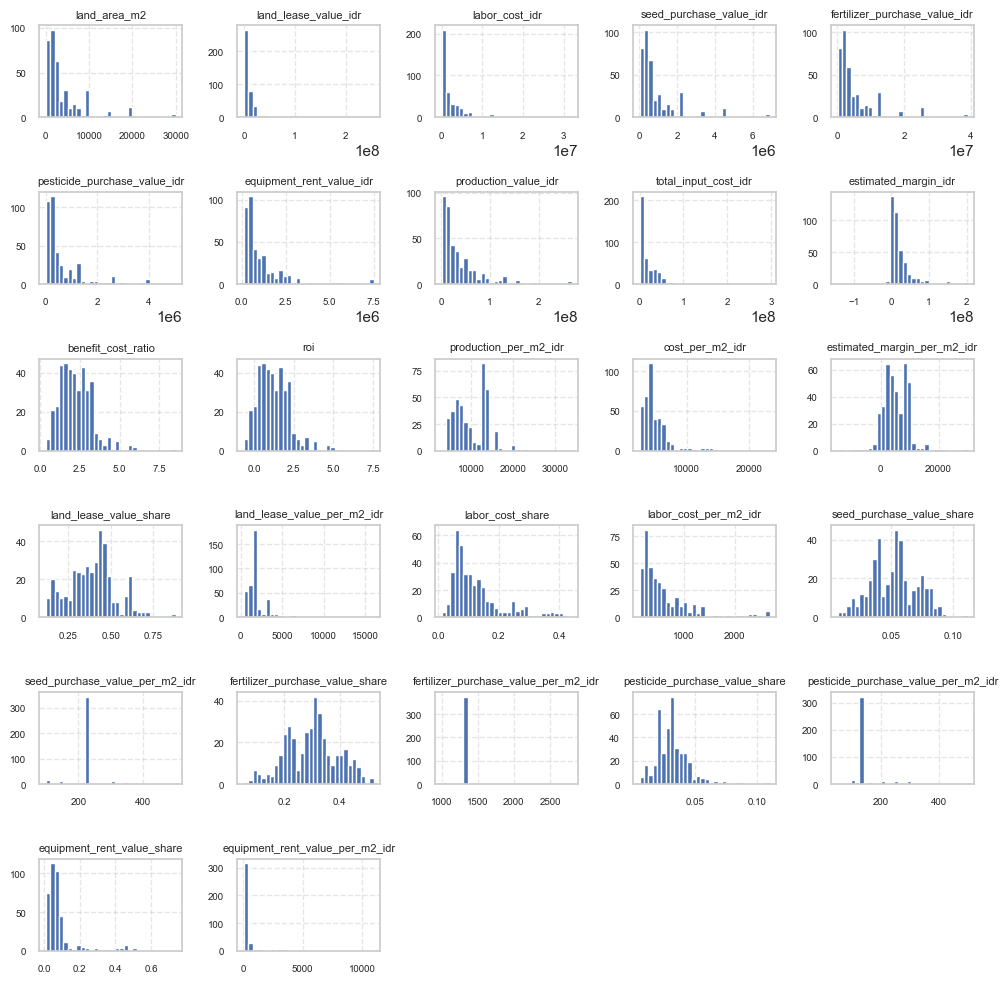

In [93]:
axes = analysis_df.hist(bins=30, figsize=(10, 10))

for ax in axes.flatten():
    ax.set_title(ax.get_title(), fontsize=8)
    ax.tick_params(axis="both", labelsize=7)
    ax.grid(linestyle="--", alpha=0.5)
    ax.set_xlabel(ax.get_xlabel(), fontsize=7)
    ax.set_ylabel(ax.get_ylabel(), fontsize=7)

plt.tight_layout()
plt.show()

## Insight Analysis

This section answers the stakeholder's business questions using production-side efficiency indicators.

In [94]:
def idr_formatter(x, pos):
    if abs(x) >= 1e9:
        return f"{x / 1e9:.1f}B"
    if abs(x) >= 1e6:
        return f"{x / 1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"{x / 1e3:.1f}K"
    return f"{x:.0f}"


def ratio_formatter(x, pos):
    return f"{x:.2f}x"


def format_chart_axis(ax, x_is_idr=False, y_is_idr=False):
    ax.grid(linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    if x_is_idr:
        ax.xaxis.set_major_formatter(FuncFormatter(idr_formatter))

    if y_is_idr:
        ax.yaxis.set_major_formatter(FuncFormatter(idr_formatter))

### 1. Which DMUs are performing best, and why?

Best performance should not be judged only by total production value. A strong DMU should generate high production value, strong estimated margin, and efficient returns relative to both input cost and land area.


In [95]:
TOP_EFFICIENT_DMU = 7

top_efficient_dmus = (
    analysis_df
    # the greater the ROI
    # while having a smaller land area
    # shown the most efficient DMU
    .sort_values(
        by=["roi", "land_area_m2"],
        ascending=[False, True]
    )
    .head(TOP_EFFICIENT_DMU)
    [
        [
            "dmu",
            "regency",
            "land_area_m2",
            "production_value_idr",
            "total_input_cost_idr",
            "estimated_margin_idr",
            "benefit_cost_ratio",
            "roi",
            "estimated_margin_per_m2_idr",
            "cost_per_m2_idr",
        ]
    ]
)

top_efficient_dmus

,dmu,regency,land_area_m2,production_value_idr,total_input_cost_idr,estimated_margin_idr,benefit_cost_ratio,roi,estimated_margin_per_m2_idr,cost_per_m2_idr
273,61,Subang,"2,000.00","67,900,000.00","7,950,000.00","59,950,000.00",8.54,7.54,"29,975.00","3,975.00"
268,56,Subang,"2,300.00","57,500,000.00","8,785,000.00","48,715,000.00",6.55,5.55,"21,180.43","3,819.57"
75,76,Unknown,"2,100.00","49,500,000.00","8,271,000.00","41,229,000.00",5.98,4.98,"19,632.86","3,938.57"
58,59,Unknown,"2,100.00","48,300,000.00","8,271,000.00","40,029,000.00",5.84,4.84,"19,061.43","3,938.57"
51,52,Unknown,"1,000.00","19,800,000.00","3,440,000.00","16,360,000.00",5.76,4.76,"16,360.00","3,440.00"
52,53,Unknown,"1,000.00","19,800,000.00","3,440,000.00","16,360,000.00",5.76,4.76,"16,360.00","3,440.00"
53,54,Unknown,"1,000.00","19,800,000.00","3,440,000.00","16,360,000.00",5.76,4.76,"16,360.00","3,440.00"


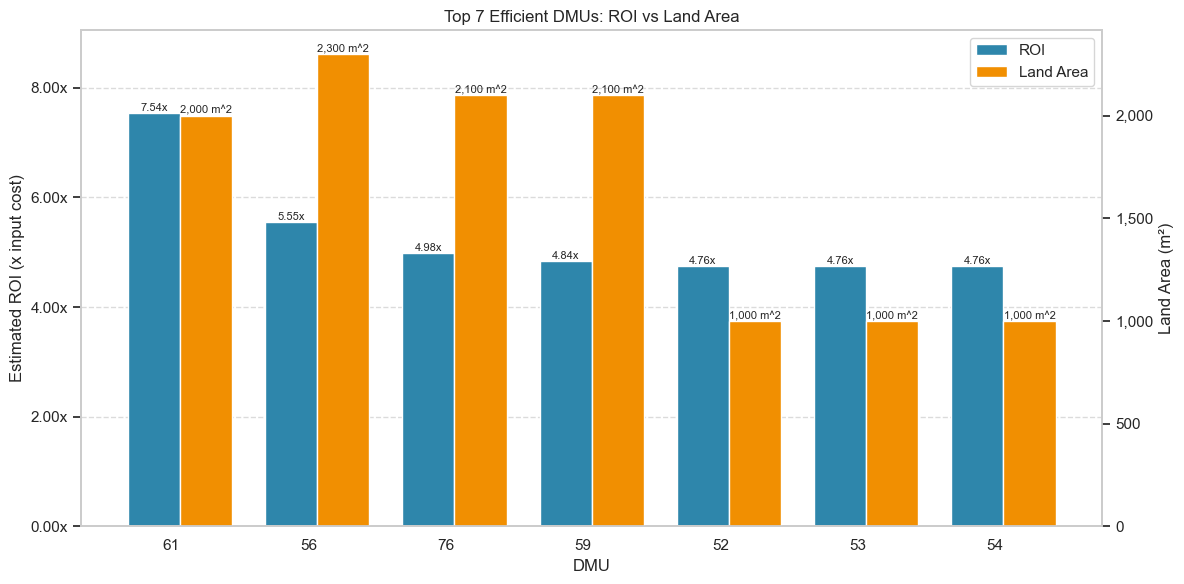

In [96]:
top_efficient_dmus_plot = top_efficient_dmus.copy()
top_efficient_dmus_plot["dmu"] = top_efficient_dmus_plot["dmu"].astype(str)

x = np.arange(len(top_efficient_dmus_plot))
width = 0.38

fig, ax1 = plt.subplots(figsize=(12, 6))

roi_bars = ax1.bar(
    x - width / 2,
    top_efficient_dmus_plot["roi"],
    width,
    label="ROI",
    color="#2E86AB"
)

ax1.set_ylabel("Estimated ROI (x input cost)")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2f}x"))
ax1.set_ylim(0, top_efficient_dmus_plot["roi"].max() * 1.2)

ax2 = ax1.twinx()

land_bars = ax2.bar(
    x + width / 2,
    top_efficient_dmus_plot["land_area_m2"],
    width,
    label="Land Area",
    color="#F18F01"
)

ax2.set_ylabel("Land Area (m²)")
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))
ax2.grid(False)

ax1.set_title(f"Top {TOP_EFFICIENT_DMU} Efficient DMUs: ROI vs Land Area")
ax1.set_xlabel("DMU")
ax1.set_xticks(x)
ax1.set_xticklabels(top_efficient_dmus_plot["dmu"], ha="right")

ax1.grid(False)
ax1.yaxis.grid(True, linestyle="--", alpha=0.7)
ax1.set_axisbelow(True)

for bar in roi_bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}x",
        ha="center",
        va="bottom",
        fontsize=8
    )

for bar in land_bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f} m^2",
        ha="center",
        va="bottom",
        fontsize=8
    )

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper right"
)

plt.tight_layout()
plt.show()

### 2. Which input cost categories dominate total cost and may hurt profitability?

This identifies where most recorded production-side spending goes. A high total cost category is important, but a high average cost share shows how strongly that category affects the typical farmer's cost structure.


In [97]:
cost_summary = (
    analysis_df[cost_cols]
    .sum()
    .sort_values(ascending=False)
)

average_cost_share = (
    analysis_df[cost_share_cols]
    .mean()
    .sort_values(ascending=False)
)

cost_structure_summary = pd.DataFrame({
    "total_cost_idr": cost_summary,
    "average_cost_share": average_cost_share.rename(
        index=lambda x: x.replace("_share", "_idr")
    )
}).sort_values("total_cost_idr", ascending=False)

cost_structure_summary

,total_cost_idr,average_cost_share
land_lease_value_idr,"3,565,685,500.00",0.39
fertilizer_purchase_value_idr,"2,356,288,500.00",0.30
labor_cost_idr,"984,597,500.00",0.13
equipment_rent_value_idr,"452,102,386.34",0.10
seed_purchase_value_idr,"408,543,927.15",0.05
pesticide_purchase_value_idr,"272,580,250.00",0.03


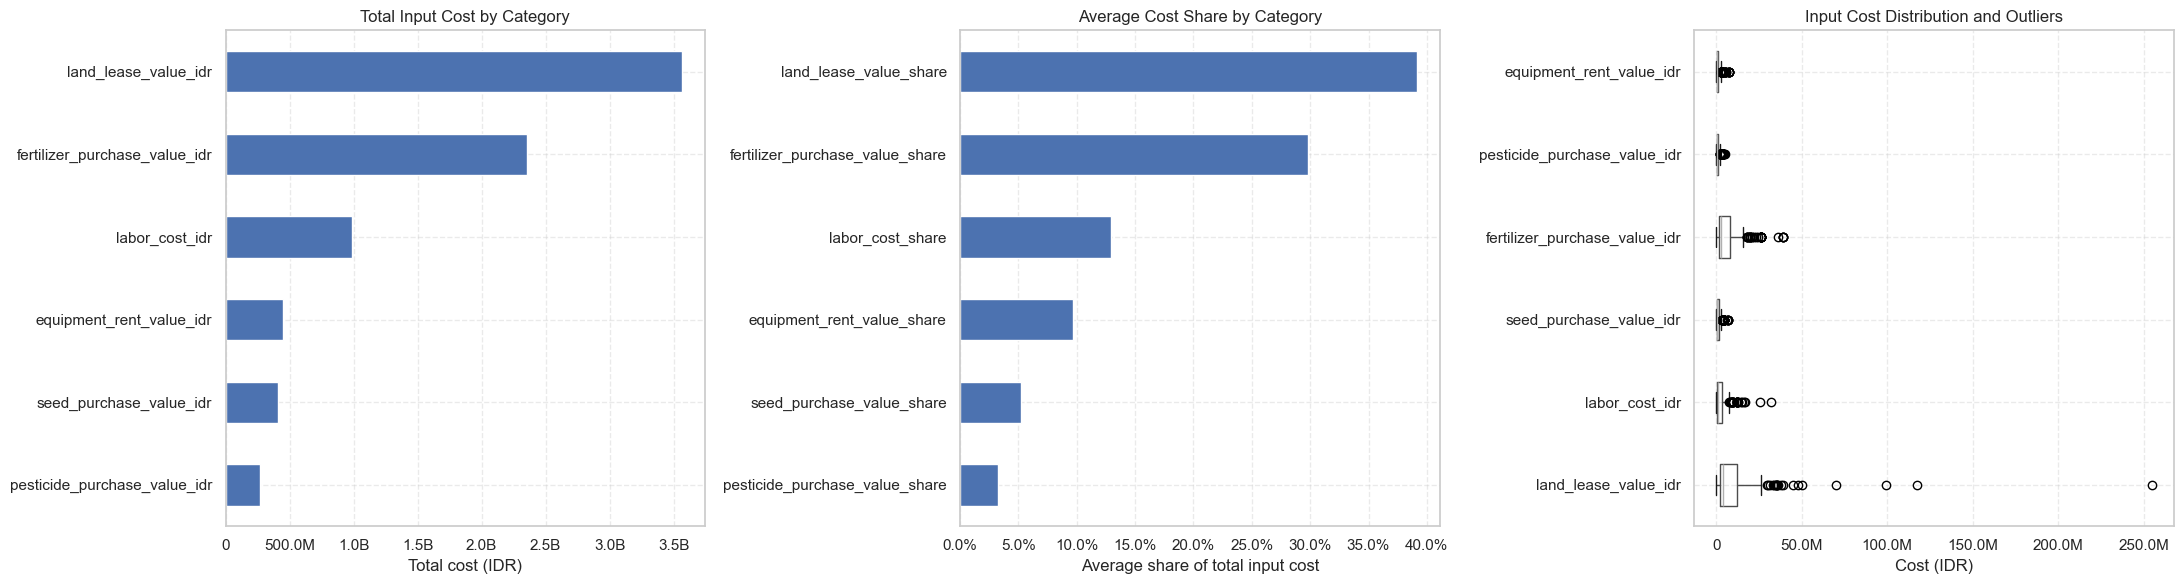

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

cost_summary.sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Total Input Cost by Category")
axes[0].set_xlabel("Total cost (IDR)")
axes[0].set_ylabel("")
format_chart_axis(axes[0], x_is_idr=True)

average_cost_share.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Average Cost Share by Category")
axes[1].set_xlabel("Average share of total input cost")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1))
format_chart_axis(axes[1])

analysis_df[cost_cols].boxplot(
    vert=False,
    ax=axes[2]
)
axes[2].set_title("Input Cost Distribution and Outliers")
axes[2].set_xlabel("Cost (IDR)")
axes[2].set_ylabel("")
format_chart_axis(axes[2], x_is_idr=True)

plt.tight_layout()
plt.show()

### 3. Which input costs have the strongest relationship with production value and estimated margin?

A positive correlation with production value may indicate that the cost scales with farm size or production intensity. A weak or negative relationship with estimated margin is more concerning because it suggests the cost may not translate into better economic return.


In [99]:
cost_relationship_summary = pd.DataFrame({
    "corr_with_production_value": analysis_df[cost_cols].corrwith(
        analysis_df["production_value_idr"]
    ),
    "corr_with_estimated_margin": analysis_df[cost_cols].corrwith(
        analysis_df["estimated_margin_idr"]
    ),
    "corr_with_benefit_cost_ratio": analysis_df[cost_cols].corrwith(
        analysis_df["benefit_cost_ratio"]
    ),
    "corr_with_roi": analysis_df[cost_cols].corrwith(
        analysis_df["roi"]
    ),
    "corr_with_margin_per_m2": analysis_df[cost_cols].corrwith(
        analysis_df["estimated_margin_per_m2_idr"]
    ),
}).sort_values("corr_with_estimated_margin", ascending=False)

cost_relationship_summary

,corr_with_production_value,corr_with_estimated_margin,corr_with_benefit_cost_ratio,corr_with_roi,corr_with_margin_per_m2
fertilizer_purchase_value_idr,0.91,0.67,0.00,0.00,-0.10
seed_purchase_value_idr,0.90,0.67,0.01,0.01,-0.10
pesticide_purchase_value_idr,0.84,0.63,0.01,0.01,-0.10
labor_cost_idr,0.70,0.45,-0.07,-0.07,-0.07
equipment_rent_value_idr,0.47,0.27,-0.16,-0.16,-0.16
land_lease_value_idr,0.51,0.01,-0.20,-0.20,-0.26


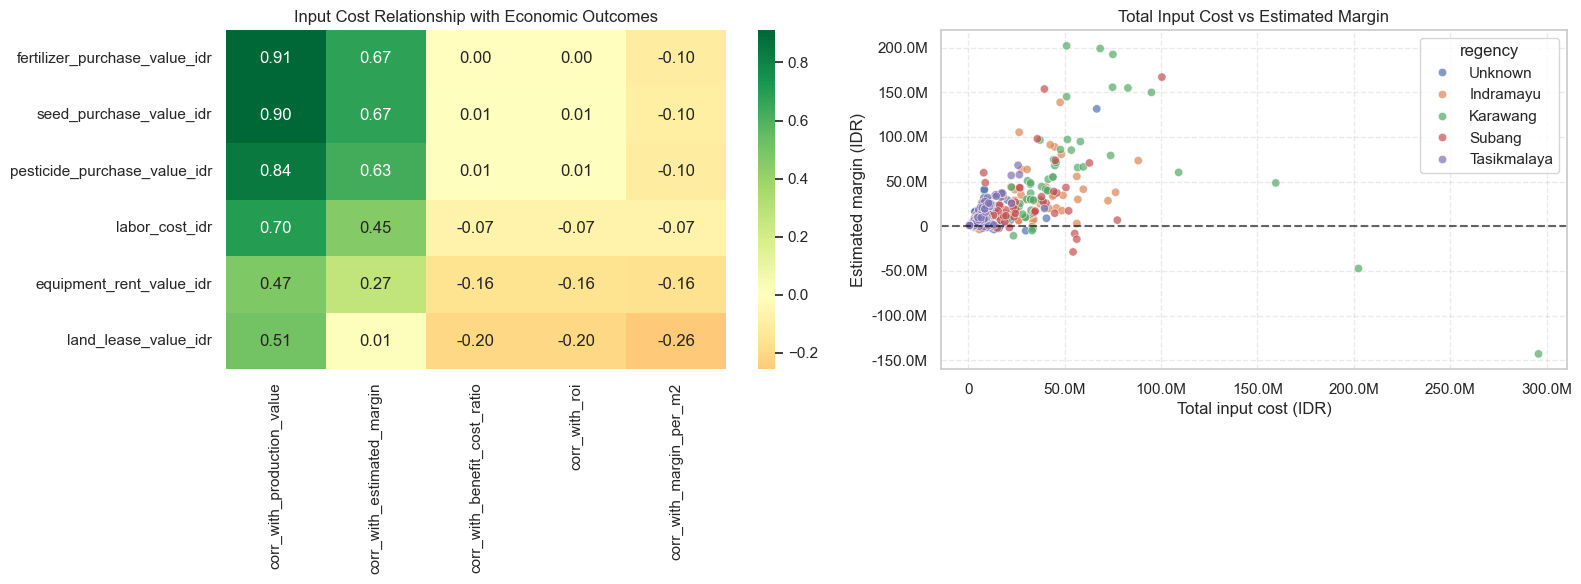

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cost_relationship_summary,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".2f",
    ax=axes[0],
)
axes[0].set_title("Input Cost Relationship with Economic Outcomes")
axes[0].set_ylabel("")

sns.scatterplot(
    data=analysis_df,
    x="total_input_cost_idr",
    y="estimated_margin_idr",
    hue="regency",
    alpha=0.7,
    ax=axes[1],
)
axes[1].axhline(0, linestyle="--", color="black", alpha=0.6)
axes[1].set_title("Total Input Cost vs Estimated Margin")
axes[1].set_xlabel("Total input cost (IDR)")
axes[1].set_ylabel("Estimated margin (IDR)")
format_chart_axis(axes[1], x_is_idr=True, y_is_idr=True)

plt.tight_layout()
plt.show()

### 4. Are larger DMUs more efficient, or do they only generate higher production value because they use more land?

This compares total production value with land-normalized and cost-normalized efficiency metrics.


In [101]:
size_relationship_summary = pd.DataFrame({
    "metric": [
        "production_value_idr",
        "estimated_margin_idr",
        "production_per_m2_idr",
        "estimated_margin_per_m2_idr",
        "benefit_cost_ratio",
        "roi",
        "cost_per_m2_idr",
    ],
    "correlation_with_land_area": [
        analysis_df["land_area_m2"].corr(analysis_df["production_value_idr"]),
        analysis_df["land_area_m2"].corr(analysis_df["estimated_margin_idr"]),
        analysis_df["land_area_m2"].corr(analysis_df["production_per_m2_idr"]),
        analysis_df["land_area_m2"].corr(analysis_df["estimated_margin_per_m2_idr"]),
        analysis_df["land_area_m2"].corr(analysis_df["benefit_cost_ratio"]),
        analysis_df["land_area_m2"].corr(analysis_df["roi"]),
        analysis_df["land_area_m2"].corr(analysis_df["cost_per_m2_idr"]),
    ]
}).sort_values("correlation_with_land_area", ascending=False)

size_relationship_summary

,metric,correlation_with_land_area
0,production_value_idr,0.91
1,estimated_margin_idr,0.68
4,benefit_cost_ratio,0.01
5,roi,0.01
3,estimated_margin_per_m2_idr,-0.10
6,cost_per_m2_idr,-0.21
2,production_per_m2_idr,-0.23


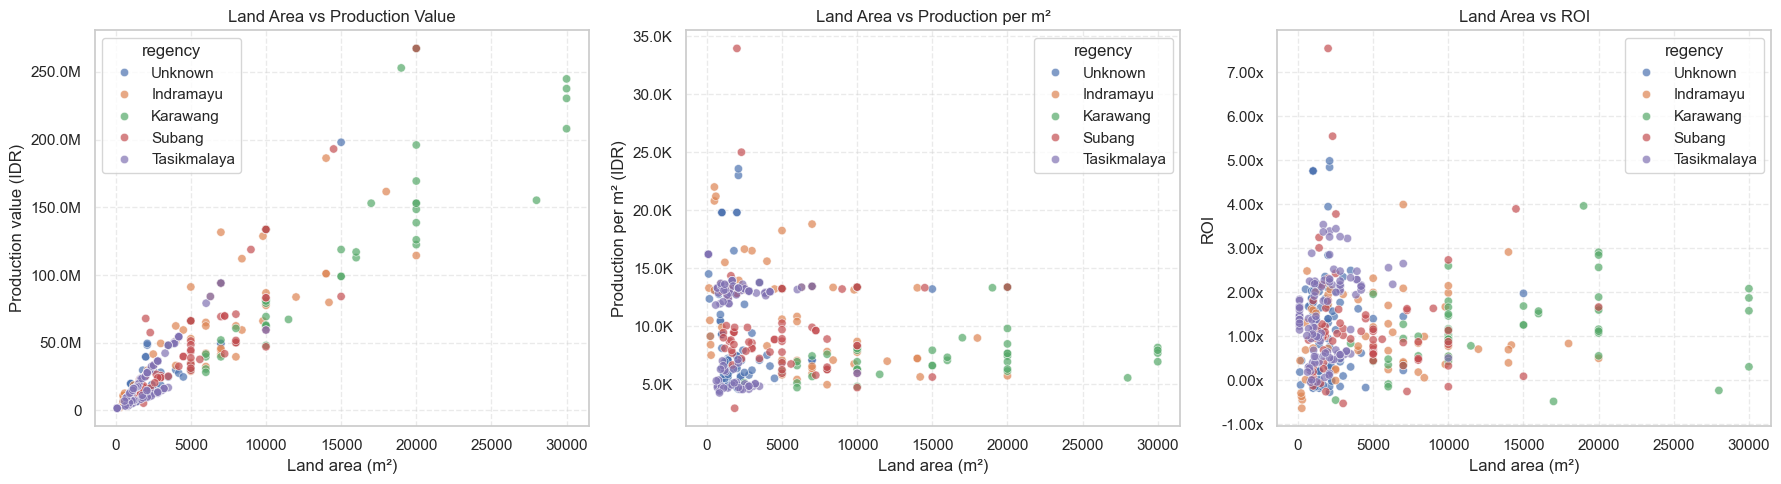

In [102]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=analysis_df,
    x="land_area_m2",
    y="production_value_idr",
    hue="regency",
    alpha=0.7,
    ax=axes[0],
)
axes[0].set_title("Land Area vs Production Value")
axes[0].set_xlabel("Land area (m²)")
axes[0].set_ylabel("Production value (IDR)")
format_chart_axis(axes[0], y_is_idr=True)

sns.scatterplot(
    data=analysis_df,
    x="land_area_m2",
    y="production_per_m2_idr",
    hue="regency",
    alpha=0.7,
    ax=axes[1],
)
axes[1].set_title("Land Area vs Production per m²")
axes[1].set_xlabel("Land area (m²)")
axes[1].set_ylabel("Production per m² (IDR)")
format_chart_axis(axes[1], y_is_idr=True)

sns.scatterplot(
    data=analysis_df,
    x="land_area_m2",
    y="roi",
    hue="regency",
    alpha=0.7,
    ax=axes[2],
)
axes[2].set_title("Land Area vs ROI")
axes[2].set_xlabel("Land area (m²)")
axes[2].set_ylabel("ROI")
axes[2].yaxis.set_major_formatter(FuncFormatter(ratio_formatter))
format_chart_axis(axes[2])

plt.tight_layout()
plt.show()

### 5. Which DMUs have high input costs but relatively low production value or estimated return?

These DMUs are strong candidates for deeper diagnosis because their recorded cost base is high but the economic outcome is weak.


In [103]:
TOP_WORST_DMUS = 20

priority_dmus = (
    analysis_df
    # ROI might not really shown the "worst" DMU because it depens on input and production unit
    # estimated margin will clearly show if it produces negative
    .sort_values(
        ["estimated_margin_idr"],
        ascending=[True]
    )
    [
        [
            "dmu",
            "regency",
            "production_value_idr",
            "total_input_cost_idr",
            "estimated_margin_idr",
            "benefit_cost_ratio",
            "roi",
        ]
    ]
    .head(TOP_WORST_DMUS)
)

priority_dmus

,dmu,regency,production_value_idr,total_input_cost_idr,estimated_margin_idr,benefit_cost_ratio,roi
176,17,Karawang,"153,000,000.00","295,820,000.00","-142,820,000.00",0.52,-0.48
205,46,Karawang,"155,200,000.00","202,430,000.00","-47,230,000.00",0.77,-0.23
256,44,Subang,"25,650,000.00","54,320,000.00","-28,670,000.00",0.47,-0.53
237,25,Subang,"41,850,000.00","56,250,000.00","-14,400,000.00",0.74,-0.26
177,18,Karawang,"12,800,000.00","23,400,000.00","-10,600,000.00",0.55,-0.45
213,1,Subang,"47,000,000.00","55,190,000.00","-8,190,000.00",0.85,-0.15
46,47,Unknown,"24,750,000.00","29,745,000.00","-4,995,000.00",0.83,-0.17
179,20,Karawang,"28,200,000.00","33,070,000.00","-4,870,000.00",0.85,-0.15
127,30,Indramayu,"2,100,000.00","5,802,500.00","-3,702,500.00",0.36,-0.64
78,79,Unknown,"9,600,000.00","13,186,000.00","-3,586,000.00",0.73,-0.27


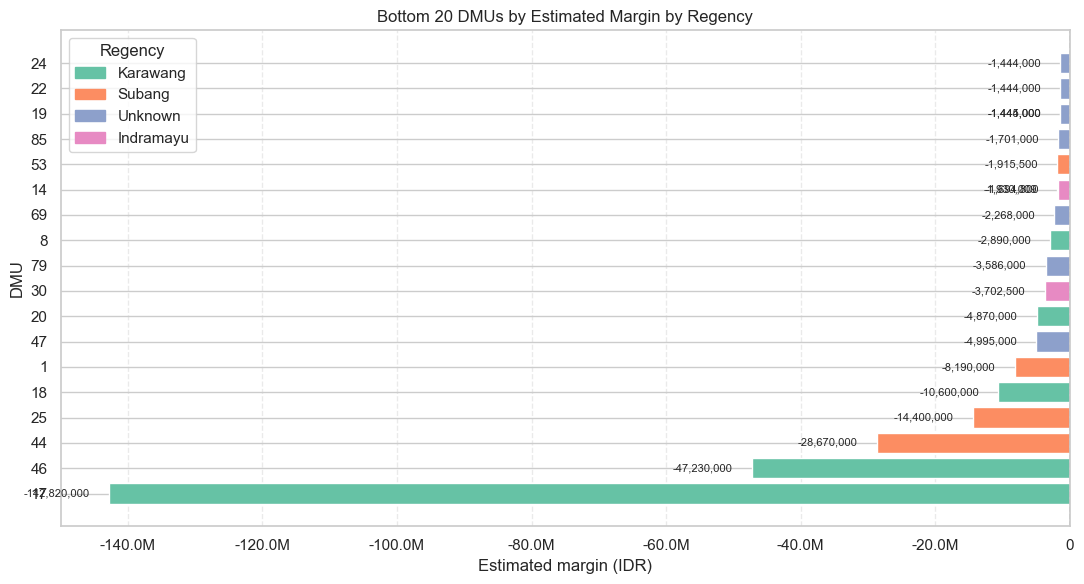

In [104]:
worst_dmus_plot = priority_dmus.sort_values("estimated_margin_idr", ascending=True).copy()
worst_dmus_plot["dmu"] = worst_dmus_plot["dmu"].astype(str)
worst_dmus_plot["regency"] = worst_dmus_plot["regency"].fillna("Unknown")

unique_regencies = worst_dmus_plot["regency"].unique()

palette = sns.color_palette("Set2", n_colors=len(unique_regencies))
regency_color_map = dict(zip(unique_regencies, palette))

colors = worst_dmus_plot["regency"].map(regency_color_map)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    worst_dmus_plot["dmu"],
    worst_dmus_plot["estimated_margin_idr"],
    color=colors
)

ax.axvline(0, color="black", linestyle="--", linewidth=1)

ax.set_title(f"Bottom {TOP_WORST_DMUS} DMUs by Estimated Margin by Regency")
ax.set_xlabel("Estimated margin (IDR)")
ax.set_ylabel("DMU")
ax.xaxis.set_major_formatter(FuncFormatter(idr_formatter))
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

for bar, margin in zip(bars, worst_dmus_plot["estimated_margin_idr"]):
    offset = abs(worst_dmus_plot["estimated_margin_idr"]).max() * 0.02

    if margin < 0:
        ha = "right"
        label_x = margin - offset
    else:
        ha = "left"
        label_x = margin + offset

    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{margin:,.0f}",
        va="center",
        ha=ha,
        fontsize=8
    )

legend_handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=regency_color_map[regency],
        label=regency
    )
    for regency in unique_regencies
]

ax.legend(
    handles=legend_handles,
    title="Regency",
    loc="best"
)

plt.tight_layout()
plt.show()

### 6. How does economic performance differ across regencies?

Regional comparison helps identify whether efficiency problems are concentrated in specific areas or spread across farmers regardless of location.


In [105]:
regency_summary = (
    analysis_df
    .groupby("regency")
    .agg(
        dmu_count=("dmu", "count"),
        avg_land_area_m2=("land_area_m2", "mean"),
        avg_production_value_idr=("production_value_idr", "mean"),
        avg_total_input_cost_idr=("total_input_cost_idr", "mean"),
        avg_estimated_margin_idr=("estimated_margin_idr", "mean"),
        avg_benefit_cost_ratio=("benefit_cost_ratio", "mean"),
        avg_roi=("roi", "mean"),
        avg_cost_per_m2_idr=("cost_per_m2_idr", "mean"),
        avg_margin_per_m2_idr=("estimated_margin_per_m2_idr", "mean"),
    )
    .sort_values("avg_roi", ascending=False)
)

regency_summary

,dmu_count,avg_land_area_m2,avg_production_value_idr,avg_total_input_cost_idr,avg_estimated_margin_idr,avg_benefit_cost_ratio,avg_roi,avg_cost_per_m2_idr,avg_margin_per_m2_idr
regency,,,,,,,,,
Tasikmalaya,110,"1,906.20","20,204,445.45","7,814,797.45","12,389,648.00",2.47,1.47,"4,645.46","6,559.79"
Unknown,98,"1,996.73","18,746,010.20","8,856,478.57","9,889,531.63",2.30,1.30,"4,672.32","5,002.88"
Subang,77,"4,318.44","42,019,409.00","21,695,363.57","20,324,045.42",2.17,1.17,"5,597.41","4,787.75"
Karawang,53,"13,575.47","109,004,754.72","54,223,584.91","54,781,169.81",2.17,1.17,"4,179.12","3,811.02"
Indramayu,62,"5,718.11","55,748,064.52","28,513,587.88","27,234,476.64",2.02,1.02,"6,524.25","4,813.85"


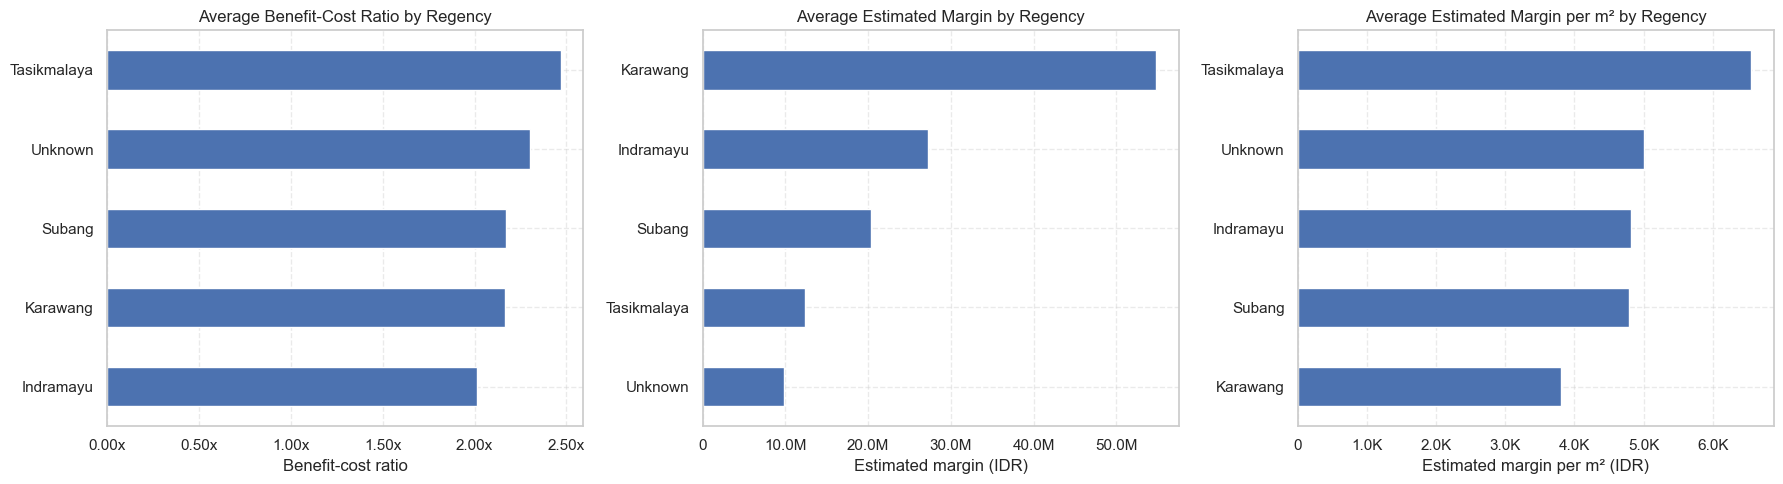

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

regency_summary["avg_benefit_cost_ratio"].sort_values().plot(
    kind="barh",
    ax=axes[0],
)
axes[0].set_title("Average Benefit-Cost Ratio by Regency")
axes[0].set_xlabel("Benefit-cost ratio")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(FuncFormatter(ratio_formatter))
format_chart_axis(axes[0])

regency_summary["avg_estimated_margin_idr"].sort_values().plot(
    kind="barh",
    ax=axes[1],
)
axes[1].set_title("Average Estimated Margin by Regency")
axes[1].set_xlabel("Estimated margin (IDR)")
axes[1].set_ylabel("")
format_chart_axis(axes[1], x_is_idr=True)

regency_summary["avg_margin_per_m2_idr"].sort_values().plot(
    kind="barh",
    ax=axes[2],
)
axes[2].set_title("Average Estimated Margin per m² by Regency")
axes[2].set_xlabel("Estimated margin per m² (IDR)")
axes[2].set_ylabel("")
format_chart_axis(axes[2], x_is_idr=True)

plt.tight_layout()
plt.show()

## Statistical Inference


### Kruskal-Wallis Test


Are these groups different enough that we have statistical evidence that regional economic performance differs?

The hypothesis:

- H0 (null): The distributions of estimated margin/m² are the same across regencies.
- H1 (alternative): At least one regency differs.


In [109]:
from scipy.stats import kruskal

# estimated margin per m2 for every regency group
regional_data = analysis_df[["regency", "estimated_margin_per_m2_idr"]].dropna()
groups = [group["estimated_margin_per_m2_idr"].values for _, group in regional_data.groupby("regency")]
group_names = regional_data["regency"].unique()

statistic, p_value = kruskal(*groups)

print("Kruskal-Wallis Test")
print("-" * 30)
print(f"H-statistic : {statistic:.4f}")
print(f"p-value     : {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("Result      : Significant difference")
    print("Conclusion  : Reject H0")
else:
    print("Result      : No significant difference")
    print("Conclusion  : Fail to reject H0")

Kruskal-Wallis Test
------------------------------
H-statistic : 23.5196
p-value     : 0.000100
Result      : Significant difference
Conclusion  : Reject H0


### Welch ANOVA Test


It asks almost the same question as Kruskal-Wallis, does the average outcomes differ across the four regencies?


In [110]:
from scipy.stats import f_oneway

result = f_oneway(*groups, equal_var=False)

print("Welch's ANOVA")
print("-" * 30)
print(f"F-statistic : {result.statistic:.4f}")
print(f"p-value     : {result.pvalue:.6f}")

alpha = 0.05

if result.pvalue < alpha:
    print("Result      : Significant difference")
    print("Conclusion  : Reject H0")
else:
    print("Result      : No significant difference")
    print("Conclusion  : Fail to reject H0")

Welch's ANOVA
------------------------------
F-statistic : 6.5170
p-value     : 0.000065
Result      : Significant difference
Conclusion  : Reject H0


Based on the result, there is statistically significant evidence that economic performance differs across regencies.

But we cannot yet say which regencies differ, this is where we need Dunn's test.


### Dunn's Post-Hoc Test


It is better to use `p_adjust="holm"` rather than using raw p-values, because the more tests we perform the greater the chance that we will accidentally get significant result just by chance. This is called the multiple-comparison problem, and holm correction adjust the p-values to reduce that problem.


In [111]:
import scikit_posthocs as sp

dunn_result = sp.posthoc_dunn(
    regional_data,
    val_col="estimated_margin_per_m2_idr",
    group_col="regency",
    p_adjust="holm"
)

print("Dunn's Post-Hoc Test")
print("-" * 30)

display(dunn_result)

Dunn's Post-Hoc Test
------------------------------


,Indramayu,Karawang,Subang,Tasikmalaya,Unknown
Indramayu,1.00,1.00,1.00,0.06,1.00
Karawang,1.00,1.00,1.00,0.00,1.00
Subang,1.00,1.00,1.00,0.01,1.00
Tasikmalaya,0.06,0.00,0.01,1.00,0.00
Unknown,1.00,1.00,1.00,0.00,1.00


Tasikmalaya appears to differ significantly from Karawang and Subang in estimated margin per m², while the differences among Indramayu, Karawang, and Subang are not statistically significant.


## OLS Inference + p-values


After controlling for the other variables, is there statistical evidence that a particular predictor is associated with production value?

The column we're particularly interested in is: P>|t|, that's the p-value for each coefficient.

The model is essentially asking if a feature cost actually had no relationship with production value after controlling for the other variables, how surprising would it be to observe a coefficient this far from zero?


In [112]:
import statsmodels.api as sm

features = [
    "land_lease_value_idr",
    "labor_cost_idr",
    "seed_purchase_value_idr",
    "fertilizer_purchase_value_idr",
    "pesticide_purchase_value_idr",
    "equipment_rent_value_idr"
]
target = "production_value_idr"

ols_data = analysis_df[
    features + [target]
].dropna()

X_ols = ols_data[features]
y_ols = ols_data[target]

# add intercept
X_ols = sm.add_constant(X_ols)

model = sm.OLS(y_ols, X_ols).fit()

# Full statistical summary
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     production_value_idr   R-squared:                       0.837
Model:                              OLS   Adj. R-squared:                  0.835
Method:                   Least Squares   F-statistic:                     337.4
Date:                  Wed, 09 Sep 2026   Prob (F-statistic):          1.27e-151
Time:                          22:23:25   Log-Likelihood:                -7278.7
No. Observations:                   400   AIC:                         1.457e+04
Df Residuals:                       393   BIC:                         1.460e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

The overall regression is statistically significant (F = 337.4, p < 0.001)

At the 5% significance level, labor cost, fertilizer cost, and equipment rental cost exhibit statistically significant positive associations with production value, while land lease value, seed cost, and pesticide cost do not show statistically significant associations after controlling for the other predictors.


## Data Preprocessing for ML Modeling


In [113]:
analysis_df.columns.to_list()

['dmu',
 'land_area_m2',
 'land_lease_value_idr',
 'labor_cost_idr',
 'seed_purchase_value_idr',
 'fertilizer_purchase_value_idr',
 'pesticide_purchase_value_idr',
 'equipment_rent_value_idr',
 'production_value_idr',
 'regency',
 'total_input_cost_idr',
 'estimated_margin_idr',
 'benefit_cost_ratio',
 'roi',
 'production_per_m2_idr',
 'cost_per_m2_idr',
 'estimated_margin_per_m2_idr',
 'land_lease_value_share',
 'land_lease_value_per_m2_idr',
 'labor_cost_share',
 'labor_cost_per_m2_idr',
 'seed_purchase_value_share',
 'seed_purchase_value_per_m2_idr',
 'fertilizer_purchase_value_share',
 'fertilizer_purchase_value_per_m2_idr',
 'pesticide_purchase_value_share',
 'pesticide_purchase_value_per_m2_idr',
 'equipment_rent_value_share',
 'equipment_rent_value_per_m2_idr']

In [114]:
exclude_from_training.append('dmu')
exclude_from_training.append('production_value_idr')

exclude_from_training

['estimated_margin_idr',
 'benefit_cost_ratio',
 'roi',
 'production_per_m2_idr',
 'estimated_margin_per_m2_idr',
 'dmu',
 'production_value_idr']

In [115]:
X_features = [f for f in analysis_df.columns.to_list() if f not in exclude_from_training]

X = analysis_df[X_features]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   land_area_m2                          400 non-null    float64
 1   land_lease_value_idr                  400 non-null    float64
 2   labor_cost_idr                        400 non-null    float64
 3   seed_purchase_value_idr               400 non-null    float64
 4   fertilizer_purchase_value_idr         400 non-null    float64
 5   pesticide_purchase_value_idr          400 non-null    float64
 6   equipment_rent_value_idr              400 non-null    float64
 7   regency                               400 non-null    object 
 8   total_input_cost_idr                  400 non-null    float64
 9   cost_per_m2_idr                       400 non-null    float64
 10  land_lease_value_share                400 non-null    float64
 11  land_lease_value_pe

In [116]:
num_cols = [col for col in X_features if col != "regency"]
cat_cols = ["regency"]

cat_cols, analysis_df["regency"].unique()

(['regency'],
 array(['Unknown', 'Indramayu', 'Karawang', 'Subang', 'Tasikmalaya'],
       dtype=object))

In [117]:
analysis_df["regency"].isna().sum(), analysis_df["regency"].isna().mean() * 100

(np.int64(0), np.float64(0.0))

In [118]:
y = analysis_df['production_value_idr']
y.head()

0   16,200,000.00
1    8,100,000.00
2   14,850,000.00
3   13,050,000.00
4   10,200,000.00
Name: production_value_idr, dtype: float64

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=analysis_df["regency"]
)

In [120]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()) # scale numeric features
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=UNK_REGENCY)), # handle NaN regency
    ("ohe", OneHotEncoder(handle_unknown="ignore")) # encode regency
])

# this preproc came with feature scaling, used in distance based models or gradient based models
preprocess_scale = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# this preproc came without feature scaling, used in OLS linear regression or tree based models
preprocess_no_scale = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", cat_pipeline, cat_cols),
])

preprocess_scale

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Regression Modeling with Linear Regression


In [121]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Linear Regression model
linear_regression = Pipeline(steps=[
    ("preprocessing", preprocess_no_scale),
    ("model", LinearRegression())
])

# Cross-validation on training set
lin_reg_scores = cross_val_score(
    linear_regression,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("CV R2 scores:", lin_reg_scores)
print("CV R2 mean:", lin_reg_scores.mean())
print("CV R2 std:", lin_reg_scores.std())

CV R2 scores: [0.83892295 0.79558992 0.66227435 0.86182159 0.79517084]
CV R2 mean: 0.7907559316853201
CV R2 std: 0.06916757036420228


In [122]:
# Fit final model on full training data
linear_regression.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [123]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "MSE": round(mse, 4),
        "RMSE": round(np.sqrt(mse), 4),
        "MAE": round(mae, 4),
        "R2": round(r2, 4)
    }

In [124]:
y_linreg_train_pred = linear_regression.predict(X_train)
y_linreg_test_pred = linear_regression.predict(X_test)

print(f"Linear regression evaluation metrics on training set = {calculate_metrics(y_train, y_linreg_train_pred)}")
print(f"Linear regression evaluation metrics on test set = {calculate_metrics(y_test, y_linreg_test_pred)}")

Linear regression evaluation metrics on training set = {'MSE': 328285138903128.7, 'RMSE': np.float64(18118640.6472), 'MAE': 11146574.5559, 'R2': 0.861}
Linear regression evaluation metrics on test set = {'MSE': 561636255221178.3, 'RMSE': np.float64(23698866.1168), 'MAE': 13284650.3175, 'R2': 0.7278}


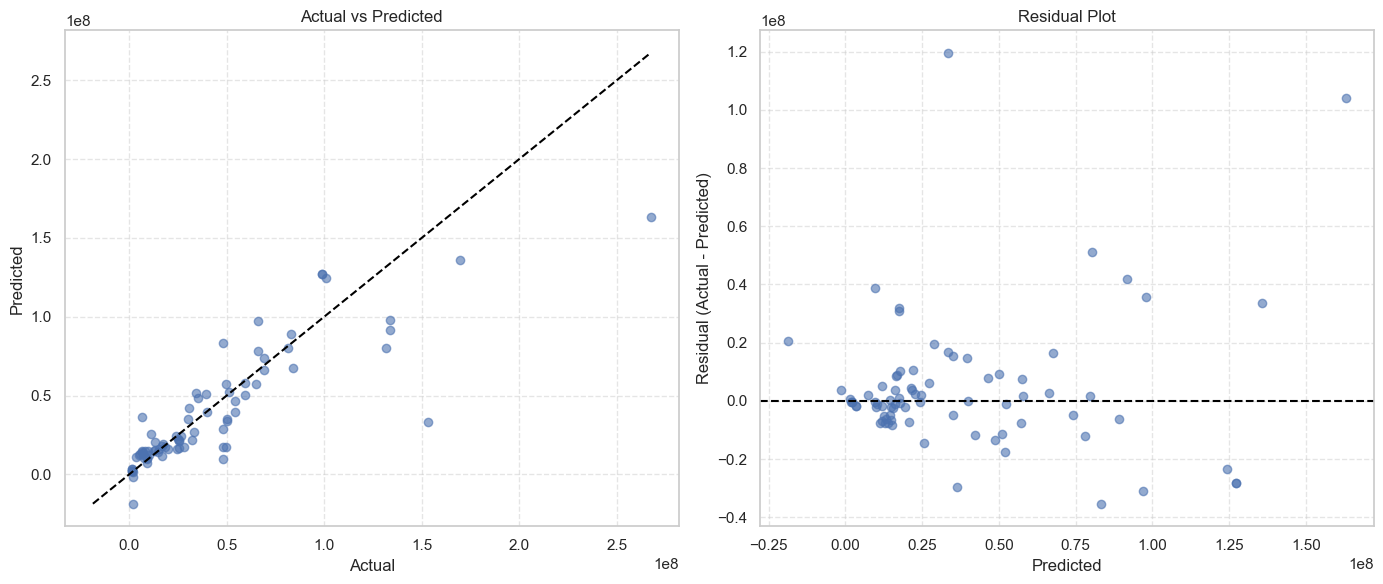

In [125]:
residuals = y_test - y_linreg_test_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(y_test, y_linreg_test_pred, alpha=0.6)

# Perfect prediction line
min_val = min(y_test.min(), y_linreg_test_pred.min())
max_val = max(y_test.max(), y_linreg_test_pred.max())

ax1.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black"
)
ax1.set_xlabel("Actual")
ax1.set_ylabel("Predicted")
ax1.set_title("Actual vs Predicted")
ax1.grid(linestyle="--", alpha=0.5)

ax2.scatter(y_linreg_test_pred, residuals, alpha=0.6)
ax2.axhline(0, linestyle="--", color="black")
ax2.set_xlabel("Predicted")
ax2.set_ylabel("Residual (Actual - Predicted)")
ax2.set_title("Residual Plot")
ax2.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

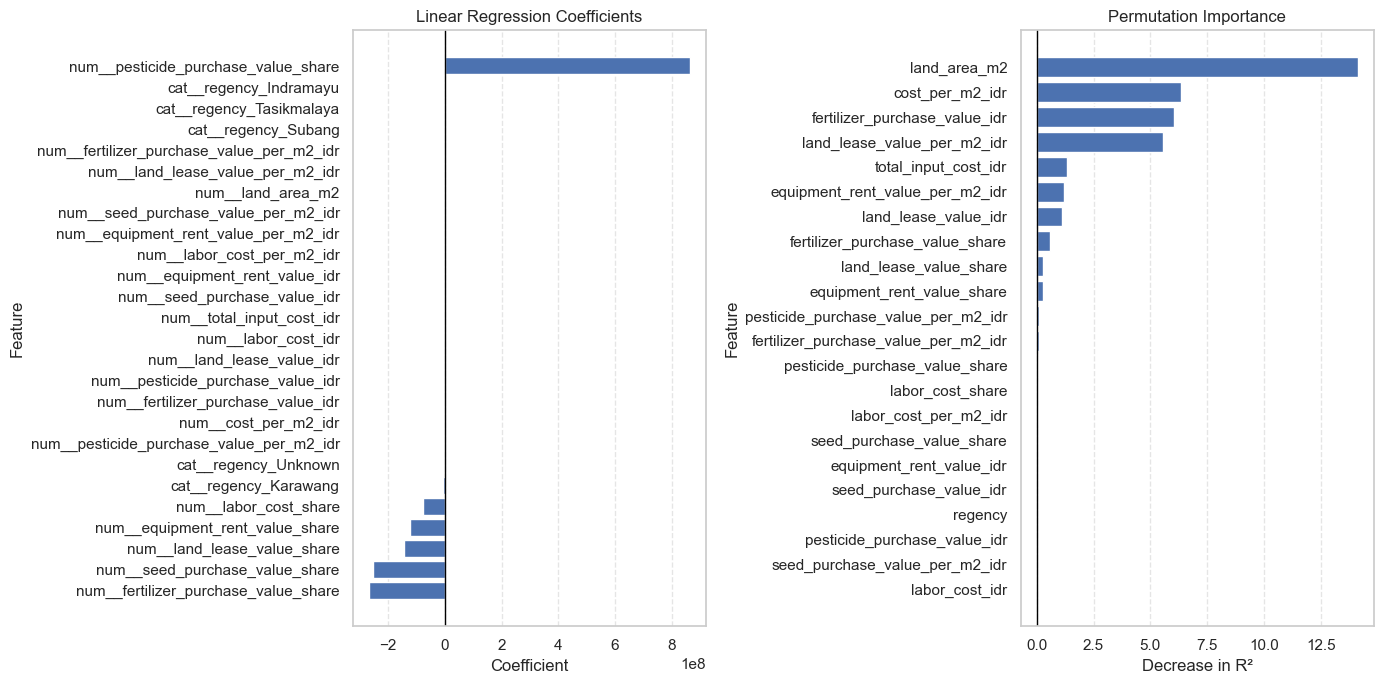

In [126]:
from sklearn.inspection import permutation_importance

feature_names = linear_regression["preprocessing"].get_feature_names_out()
coefficients = linear_regression["model"].coef_
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})
coef_df = coef_df.sort_values("coefficient")

perm_result = permutation_importance(
    linear_regression,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)
perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_result.importances_mean
}).sort_values("importance")

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 7)
)
# Coefficient plot
ax1.barh(coef_df["feature"], coef_df["coefficient"])
ax1.axvline(0, color="black", linewidth=1)
ax1.set_xlabel("Coefficient")
ax1.set_ylabel("Feature")
ax1.set_title("Linear Regression Coefficients")
ax1.grid(False)
ax1.grid(axis="x", linestyle="--", alpha=0.5)
# Permutation importance plot
ax2.barh(perm_df["feature"], perm_df["importance"])
ax2.axvline(0, color="black", linewidth=1)
ax2.set_xlabel("Decrease in R²")
ax2.set_ylabel("Feature")
ax2.set_title("Permutation Importance")
ax2.grid(False)
ax2.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Regression Modeling with Tree-based Algorithms


In [127]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

xgb = Pipeline(steps=[
    ("preprocessing", preprocess_no_scale),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__reg_lambda": [1, 5, 10],
}

xgb_grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [128]:
rf = Pipeline(steps=[
    ("preprocessing", preprocess_no_scale),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

rf_param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.7, 1.0],
}

rf_grid_search = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [129]:
rf_grid_search.fit(X_train, y_train)
xgb_grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Fitting 3 folds for each of 324 candidates, totalling 972 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more 

In [130]:
print("\nBest XGBoost Params:")
print(xgb_grid_search.best_params_)
print("\nBest XGBoost CV RMSE:")
print(-xgb_grid_search.best_score_)

xgb_best_model = xgb_grid_search.best_estimator_

print(f"XGBoost evaluation metrics on training set = {calculate_metrics(y_train, xgb_best_model.predict(X_train))}")
print(f"XGBoost evaluation metrics on test set = {calculate_metrics(y_test, xgb_best_model.predict(X_test))}")

print("Best Random Forest Params:")
print(rf_grid_search.best_params_)
print("\nBest Random Forest CV RMSE:")
print(-rf_grid_search.best_score_)

rf_best_model = rf_grid_search.best_estimator_

print(f"Random Forest evaluation metrics on training set = {calculate_metrics(y_train, rf_best_model.predict(X_train))}")
print(f"Random Forest evaluation metrics on test set = {calculate_metrics(y_test, rf_best_model.predict(X_test))}")


Best XGBoost Params:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__reg_lambda': 5, 'model__subsample': 1.0}

Best XGBoost CV RMSE:
21005438.22901557
XGBoost evaluation metrics on training set = {'MSE': 206329641463336.8, 'RMSE': np.float64(14364179.1086), 'MAE': 9269121.3664, 'R2': 0.9126}
XGBoost evaluation metrics on test set = {'MSE': 414563853830063.1, 'RMSE': np.float64(20360841.1867), 'MAE': 12463861.975, 'R2': 0.7991}
Best Random Forest Params:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100}

Best Random Forest CV RMSE:
19383482.419349287
Random Forest evaluation metrics on training set = {'MSE': 181270931048868.84, 'RMSE': np.float64(13463689.355), 'MAE': 7349660.072, 'R2': 0.9232}
Random Forest evaluation metrics on test set = {'MSE': 402211401510128.0, 'RMSE': np.float64(20055208.8374), 'MAE': 11387290.9

In [135]:
from scipy.stats import ttest_rel

rf_best_index = rf_grid_search.best_index_
xgb_best_index = xgb_grid_search.best_index_

rf_scores = np.array([
    rf_grid_search.cv_results_[f"split{i}_test_score"][rf_best_index]
    for i in range(rf_grid_search.cv)
])
xgb_scores = np.array([
    xgb_grid_search.cv_results_[f"split{i}_test_score"][xgb_best_index]
    for i in range(xgb_grid_search.cv)
])

# convert negative RMSE back to positive RMSE
rf_scores = -rf_scores
xgb_scores = -xgb_scores

print("RF scores :", rf_scores)
print("XGB scores:", xgb_scores)

t_stat, p_value = ttest_rel(
    rf_scores,
    xgb_scores
)

print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")

alpha = 0.05

print("\nPaired t-test")
print("-" * 30)
print(f"Alpha       : {alpha:.2f}")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")

if p_value < alpha:
    print("Result      : Significant difference")
    print("Conclusion  : Reject H₀")
else:
    print("Result      : No significant difference")
    print("Conclusion  : Fail to reject H₀")

RF scores : [20737712.95222543 15837643.33447794 21575090.97134449]
XGB scores: [21363847.79897989 18991371.93351508 22661094.95455174]
t-statistic : -2.0866
p-value     : 0.1722

Paired t-test
------------------------------
Alpha       : 0.05
t-statistic : -2.0866
p-value     : 0.1722
Result      : No significant difference
Conclusion  : Fail to reject H₀


Although the two models may have different average RMSE scores, the difference is not statistically significant. Therefore, based on this test, we cannot conclude that one model performs significantly better than the other.

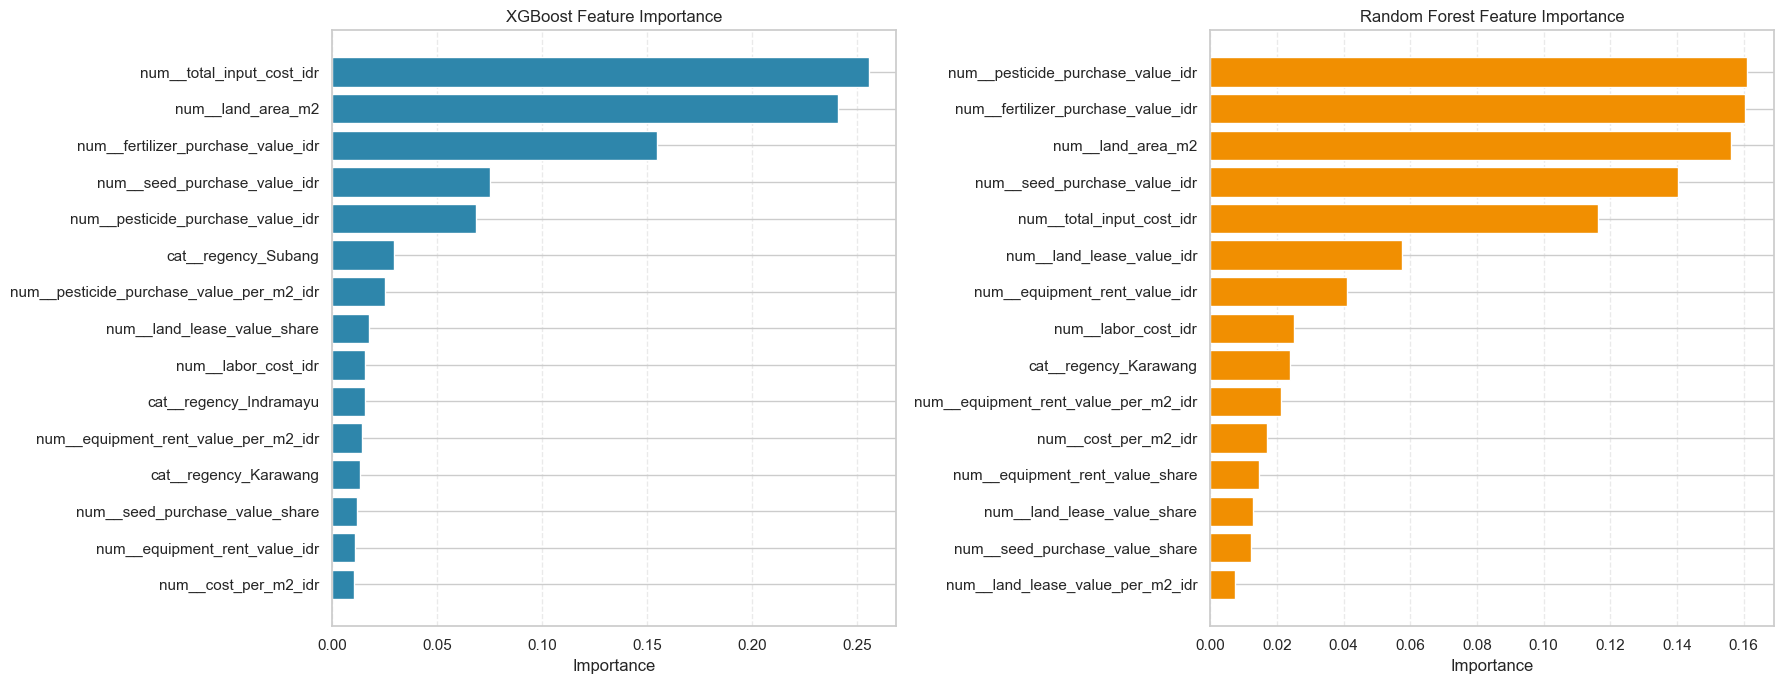

In [ ]:
def get_feature_importance(best_model):
    preprocessor = best_model.named_steps["preprocessing"]
    model = best_model.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    return importance_df

xgb_feature_importance = get_feature_importance(xgb_best_model)
rf_feature_importance = get_feature_importance(rf_best_model)

TOP_N_FEATURES = 15

xgb_top_features = (
    xgb_feature_importance
    .head(TOP_N_FEATURES)
    .sort_values("importance", ascending=True)
)

rf_top_features = (
    rf_feature_importance
    .head(TOP_N_FEATURES)
    .sort_values("importance", ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(
    xgb_top_features["feature"],
    xgb_top_features["importance"],
    color="#2E86AB"
)
axes[0].set_title("XGBoost Feature Importance")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)
axes[0].set_axisbelow(True)

axes[1].barh(
    rf_top_features["feature"],
    rf_top_features["importance"],
    color="#F18F01"
)
axes[1].set_title("Random Forest Feature Importance")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

## DMU Clustering / Segmentation


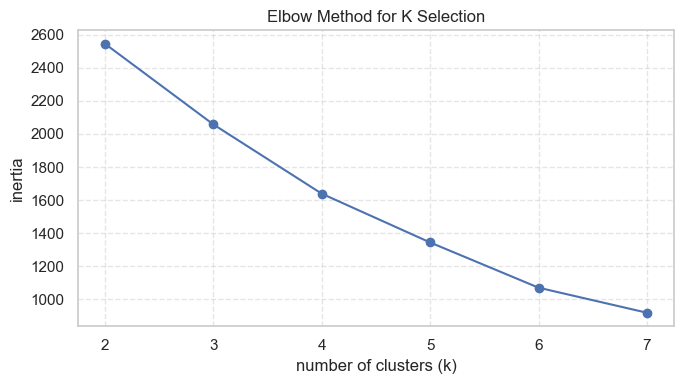

In [136]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans

cluster_features = [
    "land_area_m2",
    "total_input_cost_idr",
    "production_value_idr",
    "estimated_margin_idr",
    "benefit_cost_ratio",
    "roi",
    "production_per_m2_idr",
    "cost_per_m2_idr",
    "estimated_margin_per_m2_idr",
]

robust_scaler = RobustScaler()
X_cluster = robust_scaler.fit_transform(analysis_df[cluster_features])

# use 3 clusters
inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker="o")
ax.set_xlabel("number of clusters (k)")
ax.set_ylabel("inertia")
ax.set_title("Elbow Method for K Selection")
ax.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [137]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
analysis_df["cluster"] = km.fit_predict(X_cluster)

cluster_summary = (
    analysis_df
    .groupby("cluster")
    .agg(
        dmu_count=("dmu", "count"),
        avg_land_area_m2=("land_area_m2", "mean"),
        avg_total_input_cost_idr=("total_input_cost_idr", "mean"),
        avg_production_value_idr=("production_value_idr", "mean"),
        avg_estimated_margin_idr=("estimated_margin_idr", "mean"),
        avg_roi=("roi", "mean"),
        avg_cost_per_m2_idr=("cost_per_m2_idr", "mean"),
        avg_estimated_margin_per_m2_idr=("estimated_margin_per_m2_idr", "mean"),
    )
    .sort_values("avg_estimated_margin_idr")
)

cluster_summary

,dmu_count,avg_land_area_m2,avg_total_input_cost_idr,avg_production_value_idr,avg_estimated_margin_idr,avg_roi,avg_cost_per_m2_idr,avg_estimated_margin_per_m2_idr
cluster,,,,,,,,
1,28,"1,963.93","26,395,818.18","22,830,357.14","-3,565,461.04",0.05,"12,666.67",-176.52
2,187,"4,430.91","19,588,900.90","32,148,061.46","12,559,160.55",0.64,"4,522.82","2,569.58"
3,147,"1,868.26","7,946,902.62","25,483,435.37","17,536,532.75",2.15,"4,615.57","9,295.82"
0,38,"17,202.63","64,984,105.26","161,361,105.26","96,377,000.00",1.77,"3,867.44","6,286.92"


In [138]:
cluster_name_map = {
    0: "Large-scale high-value producers",
    1: "Loss-making / at-risk producers",
    2: "Stable medium-scale producers",
    3: "Efficient small-scale producers",
}

analysis_df["cluster_name"] = analysis_df["cluster"].map(cluster_name_map)

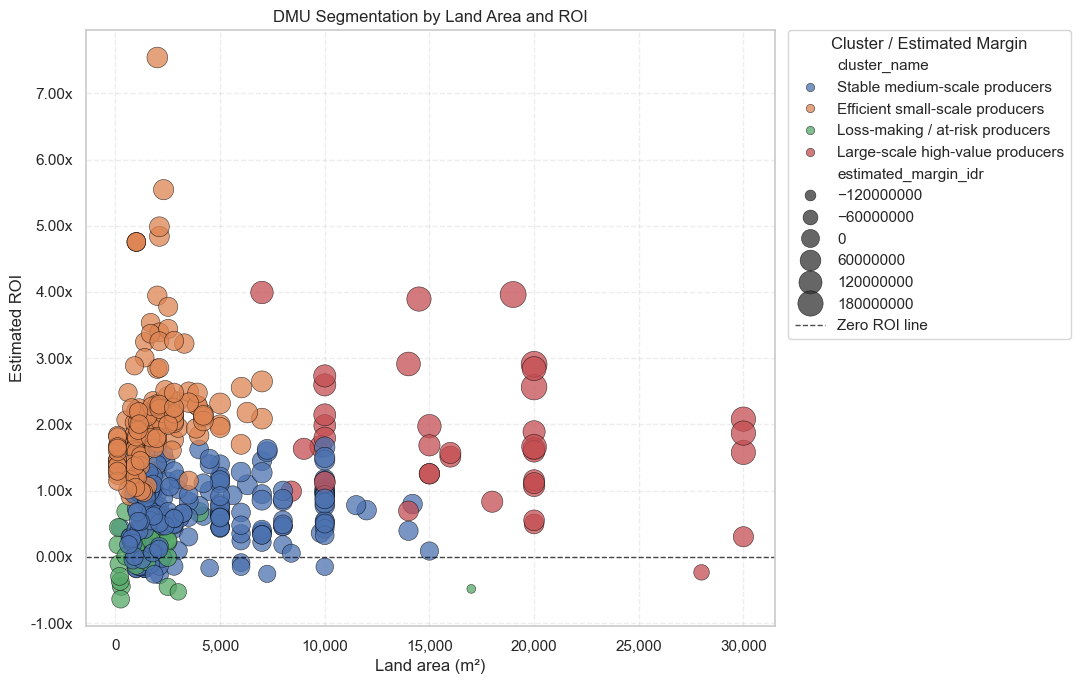

In [139]:
fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=analysis_df,
    x="land_area_m2",
    y="roi",
    hue="cluster_name",
    size="estimated_margin_idr",
    sizes=(40, 350),
    alpha=0.75,
    edgecolor="black",
    linewidth=0.4,
    ax=ax
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="Zero ROI line"
)
ax.set_title("DMU Segmentation by Land Area and ROI")
ax.set_xlabel("Land area (m²)")
ax.set_ylabel("Estimated ROI")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2f}x"))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))
ax.grid(linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.legend(title="Cluster / Estimated Margin",
          bbox_to_anchor=(1.02, 1),
          loc="upper left",
          borderaxespad=0
)

plt.tight_layout()
plt.show()

In [140]:
cluster_profile_plot = (
    analysis_df
    .groupby("cluster_name")
    .agg(
        dmu_count=("dmu", "count"),
        avg_land_area_m2=("land_area_m2", "mean"),
        avg_total_input_cost_idr=("total_input_cost_idr", "mean"),
        avg_estimated_margin_idr=("estimated_margin_idr", "mean"),
        avg_roi=("roi", "mean"),
    )
    .reset_index()
)

cluster_profile_plot

,cluster_name,dmu_count,avg_land_area_m2,avg_total_input_cost_idr,avg_estimated_margin_idr,avg_roi
0,Efficient small-scale producers,147,"1,868.26","7,946,902.62","17,536,532.75",2.15
1,Large-scale high-value producers,38,"17,202.63","64,984,105.26","96,377,000.00",1.77
2,Loss-making / at-risk producers,28,"1,963.93","26,395,818.18","-3,565,461.04",0.05
3,Stable medium-scale producers,187,"4,430.91","19,588,900.90","12,559,160.55",0.64


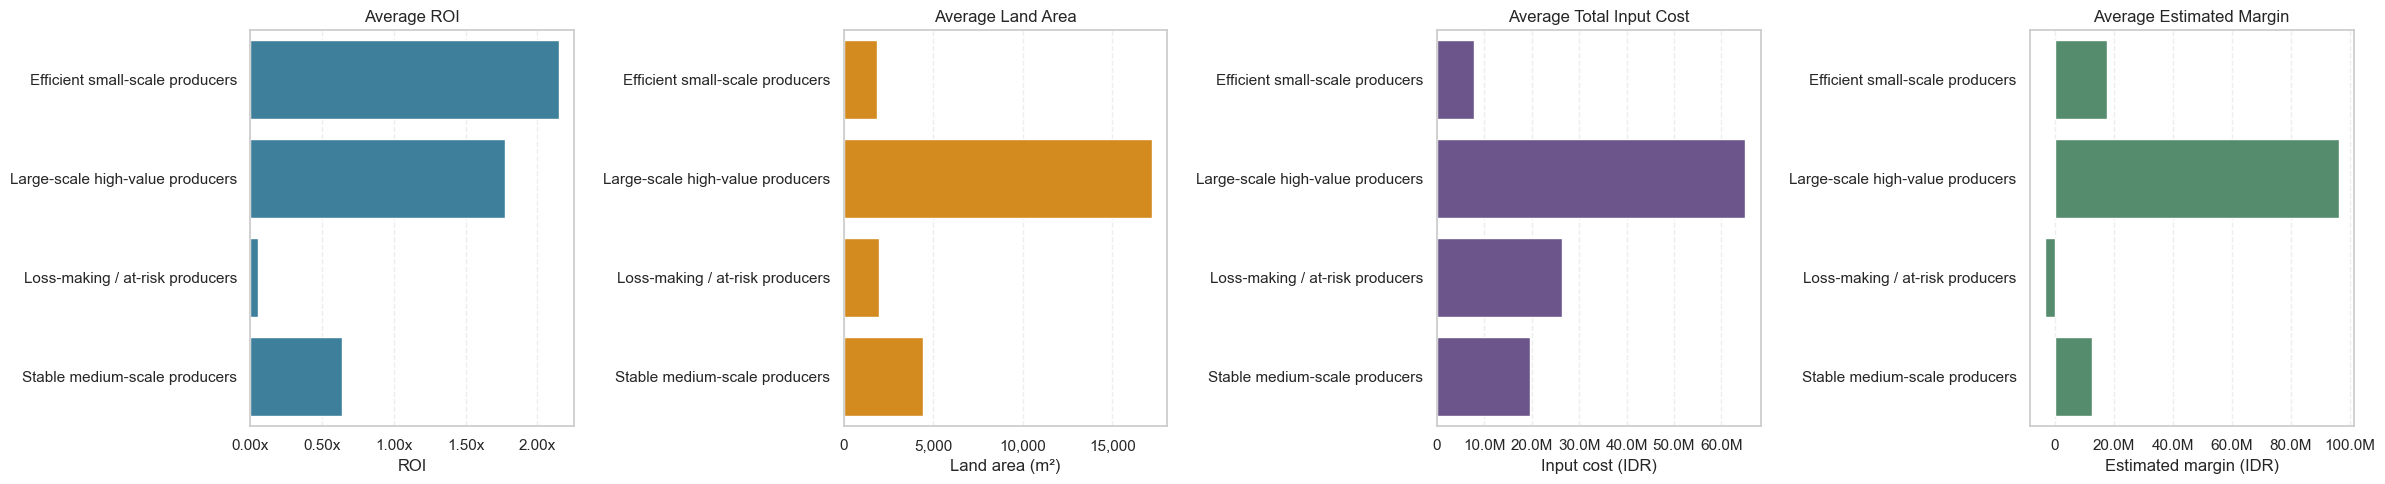

In [141]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

sns.barplot(
    data=cluster_profile_plot,
    x="avg_roi",
    y="cluster_name",
    ax=axes[0],
    color="#2E86AB"
)
axes[0].set_title("Average ROI")
axes[0].set_xlabel("ROI")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2f}x"))

sns.barplot(
    data=cluster_profile_plot,
    x="avg_land_area_m2",
    y="cluster_name",
    ax=axes[1],
    color="#F18F01"
)
axes[1].set_title("Average Land Area")
axes[1].set_xlabel("Land area (m²)")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))

sns.barplot(
    data=cluster_profile_plot,
    x="avg_total_input_cost_idr",
    y="cluster_name",
    ax=axes[2],
    color="#6A4C93"
)
axes[2].set_title("Average Total Input Cost")
axes[2].set_xlabel("Input cost (IDR)")
axes[2].set_ylabel("")
axes[2].xaxis.set_major_formatter(FuncFormatter(idr_formatter))

sns.barplot(
    data=cluster_profile_plot,
    x="avg_estimated_margin_idr",
    y="cluster_name",
    ax=axes[3],
    color="#4C956C"
)
axes[3].set_title("Average Estimated Margin")
axes[3].set_xlabel("Estimated margin (IDR)")
axes[3].set_ylabel("")
axes[3].xaxis.set_major_formatter(FuncFormatter(idr_formatter))

for ax in axes:
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [142]:
print("finished")

finished
